# Alonso vs Slot: The Tactical Fit for Liverpool

This notebook analyzes why Liverpool's data department may have favored Arne Slot's evolutionary continuity over Xabi Alonso's revolutionary shift, using Understat data (xG, PPDA, and Shot Metrics).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path

# Add src to path to use our library
sys.path.insert(0, '/Users/gauravahlawat/git_projects/football-analytics-alonso/src')
from football_analytics.processors import UnderstatProcessor

sns.set_theme(style="whitegrid")

# Load Match xG Data
liv_match = pd.read_csv('../data/processed/understat/liverpool_match_xg.csv')
lev_match = pd.read_csv('../data/processed/understat/bayer_leverkusen_match_xg.csv')

# Load PPDA Data
liv_ppda = pd.read_csv('../data/processed/understat/liverpool_ppda.csv')
lev_ppda = pd.read_csv('../data/processed/understat/bayer_leverkusen_ppda.csv')

# Ensure Date Format
liv_match['date'] = pd.to_datetime(liv_match['date'])
liv_ppda['date'] = pd.to_datetime(liv_ppda['date'])
lev_match['date'] = pd.to_datetime(lev_match['date'])
lev_ppda['date'] = pd.to_datetime(lev_ppda['date'])

# Merge Data
liv_merged = pd.merge(liv_match, liv_ppda, on=['season', 'date'], how='inner')
liv_merged['team'] = 'Liverpool'
liv_merged['manager'] = liv_merged['season'].apply(lambda x: 'Klopp' if x in [2022, 2023] else 'Slot')

lev_merged = pd.merge(lev_match, lev_ppda, on=['season', 'date'], how='inner')
lev_merged['team'] = 'Bayer Leverkusen'

# Use our library processor to filter out Gerardo Seoane's matches (Alonso took over Oct 5, 2022)
lev_merged = UnderstatProcessor.filter_by_date(lev_merged, start_date='2022-10-05')
lev_merged['manager'] = 'Alonso'

df = pd.concat([liv_merged, lev_merged], ignore_index=True)


## 1. Pressing Intensity (PPDA)
A lower PPDA indicates more intense pressing. Klopp's Liverpool was famous for heavy-metal Gegenpressing. Did Alonso match this intensity?

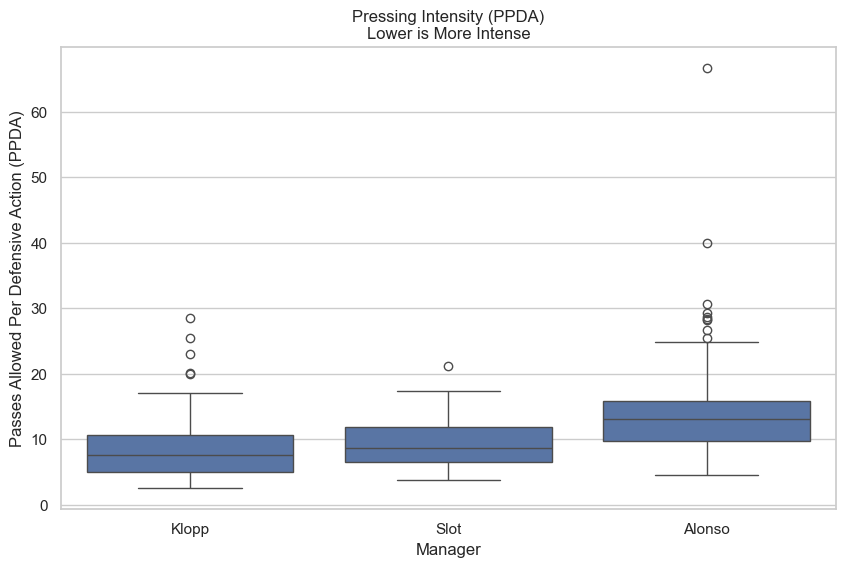

In [2]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='manager', y='ppda', data=df, order=['Klopp', 'Slot', 'Alonso'])
plt.title('Pressing Intensity (PPDA)\nLower is More Intense')
plt.ylabel('Passes Allowed Per Defensive Action (PPDA)')
plt.xlabel('Manager')
plt.savefig('../figures/ppda_comparison.png')
plt.show()

## 2. Attacking Output (Non-Penalty xG)
Using our `UnderstatProcessor` to calculate true npxG.

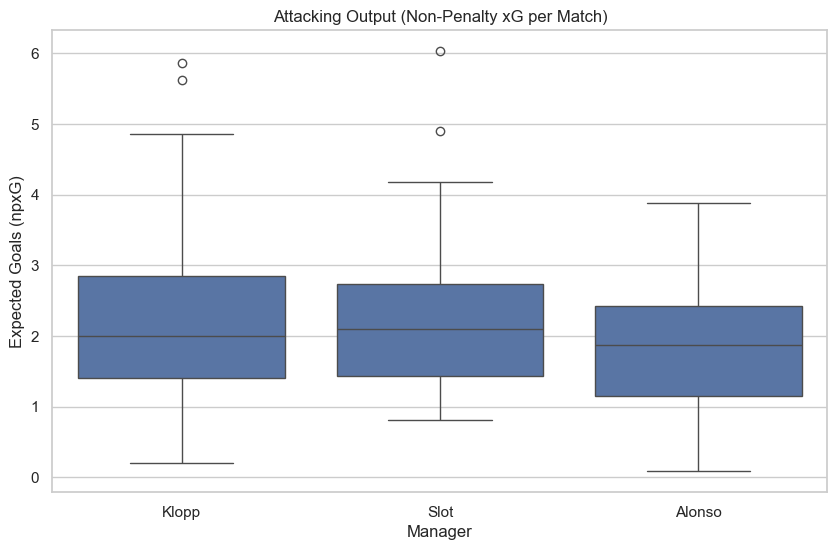

In [3]:
# Load Shots Data
liv_shots = pd.read_csv('../data/processed/understat/liverpool_shots.csv')
liv_shots['date'] = pd.to_datetime(liv_shots['date'])
liv_shots['manager'] = liv_shots['season'].apply(lambda x: 'Klopp' if x in [2022, 2023] else 'Slot')
liv_shots['team'] = 'Liverpool'

lev_shots = pd.read_csv('../data/processed/understat/bayer_leverkusen_shots.csv')
# Filter Seoane matches from shots using the processor
lev_shots = UnderstatProcessor.filter_by_date(lev_shots, start_date='2022-10-05')
lev_shots['manager'] = 'Alonso'
lev_shots['team'] = 'Bayer Leverkusen'

shots_df = pd.concat([liv_shots, lev_shots], ignore_index=True)

# Calculate Match-level npxG using our processor
match_npxg = UnderstatProcessor.calculate_match_npxg(shots_df)

# Merge manager names back for plotting
manager_map = shots_df[['understat_match_id', 'manager']].drop_duplicates()
match_npxg = match_npxg.merge(manager_map, on='understat_match_id')

plt.figure(figsize=(10, 6))
sns.boxplot(x='manager', y='npxG', data=match_npxg, order=['Klopp', 'Slot', 'Alonso'])
plt.title('Attacking Output (Non-Penalty xG per Match)')
plt.ylabel('Expected Goals (npxG)')
plt.xlabel('Manager')
plt.savefig('../figures/npxg_comparison.png')
plt.show()

## 3. Shot Distances (Directness & Pitch Geometry)
Calculating true Euclidean pitch distance utilizing the `UnderstatProcessor` library.

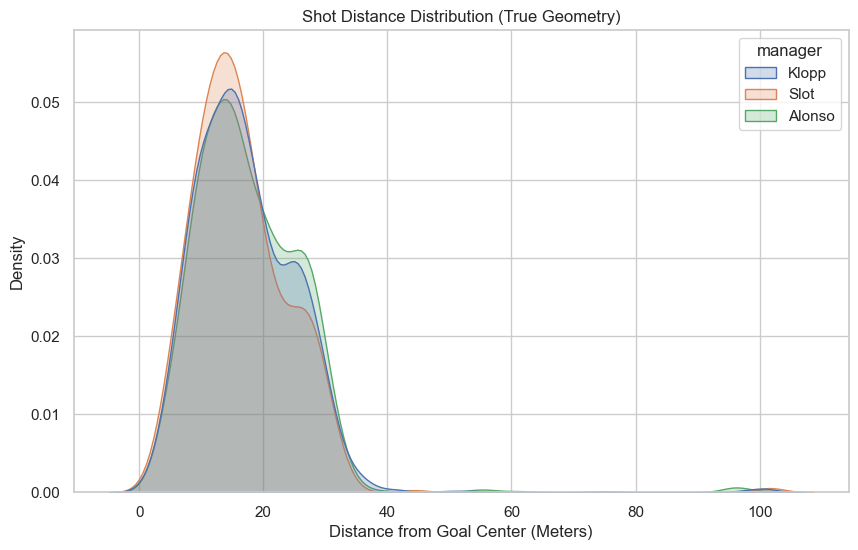

In [4]:
# Calculate True Pitch Geometry Distance using our processor
shots_df = UnderstatProcessor.calculate_true_shot_distance(shots_df)

plt.figure(figsize=(10, 6))
sns.kdeplot(data=shots_df, x='real_distance_m', hue='manager', common_norm=False, fill=True)
plt.title('Shot Distance Distribution (True Geometry)')
plt.xlabel('Distance from Goal Center (Meters)')
plt.savefig('../figures/shot_distance_comparison.png')
plt.show()